# Dự đoán Nguy cơ Tái nhập viện của Bệnh nhân Đái tháo đường

## Bài toán
Tái nhập viện xảy ra khi một bệnh nhân đã được xuất viện quay trở lại bệnh viện trong một khoảng thời gian nhất định. Tỷ lệ tái nhập viện cao thường phản ánh chất lượng điều trị hoặc chăm sóc sau xuất viện chưa tốt, đồng thời làm gia tăng chi phí y tế.

## Mục tiêu
Sử dụng bộ dữ liệu hồ sơ bệnh án để trả lời các câu hỏi sau:
- Các yếu tố nào ảnh hưởng mạnh nhất đến khả năng tái nhập viện của bệnh nhân đái tháo đường?
- Có thể dự đoán nguy cơ tái nhập viện với độ chính xác cao khi chỉ sử dụng một số lượng đặc trưng hạn chế hay không?

## Quy trình thực hiện

### 1. Phân tích dữ liệu
Khảo sát thông tin bệnh nhân và các lần điều trị nhằm xác định các đặc trưng có giá trị phục vụ cho việc dự đoán.

### 2. Xác định các yếu tố ảnh hưởng
Phân tích các yếu tố như:
- Chẩn đoán bệnh
- Thuốc điều trị
- Thời gian nằm viện
- Số lần nhập viện trước đó
- Kết quả xét nghiệm

--> để xác định mức độ ảnh hưởng của chúng đến khả năng tái nhập viện.

### 3. Xây dựng mô hình dự đoán
Huấn luyện mô hình Machine Learning bằng cách sử dụng các đặc trưng phù hợp để dự đoán nguy cơ tái nhập viện.

### 4. Đánh giá mô hình
Đánh giá hiệu quả mô hình thông qua các chỉ số:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
Đồng thời phân tích mức độ quan trọng của từng đặc trưng đối với kết quả dự đoán.

## Các biến chính

| **Tên biến** | **Mô tả** | **Kiểu dữ liệu / Giá trị** |
|--------------|-----------|----------------------------|
| Encounter ID | Mã định danh duy nhất của mỗi lần khám | Numeric |
| Patient Number | Mã định danh duy nhất của bệnh nhân | Numeric |
| Race | Chủng tộc của bệnh nhân | Caucasian, Asian, African American, Hispanic, Other |
| Gender | Giới tính của bệnh nhân | Male, Female, Unknown/Invalid |
| Age | Nhóm tuổi của bệnh nhân | 10-year intervals (e.g., [0-10), [10-20), …, [90-100)) |
| Weight | Cân nặng của bệnh nhân | Pounds (Numeric) |
| Admission Type | Loại nhập viện | 9 values (e.g., Emergency, Urgent, Elective) |
| Discharge Disposition | Tình trạng xuất viện | 29 values (e.g., Home, Expired) |
| Admission Source | Nguồn nhập viện | 21 values (e.g., Physician Referral, Emergency Room) |
| Time in Hospital | Số ngày nằm viện | Integer |
| Payer Code | Mã đơn vị thanh toán bảo hiểm | 23 values (e.g., Medicare, Self-Pay) |
| Medical Specialty | Chuyên khoa của bác sĩ điều trị | 84 values (e.g., Cardiology, Internal Medicine) |
| Number of Lab Procedures | Số lượng xét nghiệm được thực hiện | Numeric |
| Number of Procedures | Số lượng thủ thuật điều trị | Numeric |
| Number of Medications | Số lượng thuốc được kê | Numeric |
| Number of Outpatient Visits | Số lần khám ngoại trú trong năm trước | Numeric |
| Number of Emergency Visits | Số lần cấp cứu trong năm trước | Numeric |
| Number of Inpatient Visits | Số lần điều trị nội trú trong năm trước | Numeric |
| Diagnosis 1 | Chẩn đoán chính | ICD9 first 3 digits (848 values) |
| Diagnosis 2 | Chẩn đoán phụ thứ nhất | ICD9 first 3 digits (923 values) |
| Diagnosis 3 | Chẩn đoán phụ thứ hai | ICD9 first 3 digits (954 values) |
| Number of Diagnoses | Tổng số chẩn đoán | Numeric |
| Glucose Serum Test Result | Kết quả xét nghiệm đường huyết | >200, >300, Normal, None |
| A1c Test Result | Kết quả xét nghiệm HbA1c | >8%, >7%, Normal, None |
| Change of Medications | Thay đổi thuốc điều trị đái tháo đường | Change, No Change |
| Diabetes Medications | Có sử dụng thuốc điều trị đái tháo đường | Yes, No |
| Medication Features (24) | Trạng thái của 24 loại thuốc điều trị đái tháo đường (ví dụ: metformin, insulin) | Up, Down, Steady, No |
| Readmitted | Thời gian tái nhập viện | <30 days, >30 days, No |

---

## Bộ dữ liệu sử dụng
- **Tên bộ dữ liệu:** Diabetes 130-US Hospitals for Years 1999–2008
- **Lĩnh vực:** Healthcare, Machine Learning
- **Đối tượng nghiên cứu:** Bệnh nhân mắc bệnh đái tháo đường
- **Biến mục tiêu:** Readmitted

---

## Kết quả mong đợi

Sau khi hoàn thành dự án, mô hình có thể:

- Phân tích các yếu tố ảnh hưởng đến nguy cơ tái nhập viện.
- Dự đoán khả năng tái nhập viện của bệnh nhân.
- So sánh hiệu quả giữa các thuật toán Machine Learning.
- Xác định các đặc trưng quan trọng nhất hỗ trợ bác sĩ trong việc đánh giá nguy cơ tái nhập viện.

In [1]:
!pip install imblearn

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, precision_recall_curve, auc
from imblearn.over_sampling import ADASYN
from sklearn.feature_selection import VarianceThreshold, RFE
import warnings
warnings.filterwarnings('ignore')

# Tiền xử lý dữ liệu 

In [6]:
df = pd.read_csv("diabetic_data.csv")

In [7]:
df.head(10).T

,0,1,2,3,4,5,6,7,8,9
encounter_id,2278392,149190,64410,500364,16680,35754,55842,63768,12522,15738
patient_nbr,8222157,55629189,86047875,82442376,42519267,82637451,84259809,114882984,48330783,63555939
race,Caucasian,Caucasian,AfricanAmerican,Caucasian,Caucasian,Caucasian,Caucasian,Caucasian,Caucasian,Caucasian
gender,Female,Female,Female,Male,Male,Male,Male,Male,Female,Female
age,[0-10),[10-20),[20-30),[30-40),[40-50),[50-60),[60-70),[70-80),[80-90),[90-100)
weight,?,?,?,?,?,?,?,?,?,?
admission_type_id,6,1,1,1,1,2,3,1,2,3
discharge_disposition_id,25,1,1,1,1,1,1,1,1,3
admission_source_id,1,7,7,7,7,2,2,7,4,4
time_in_hospital,1,3,2,2,1,3,4,5,13,12


In [8]:
df.shape

(101766, 50)

In [9]:
df.dtypes

encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride         

In [10]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [11]:
df.max_glu_serum.unique()

array([nan, '>300', 'Norm', '>200'], dtype=object)

In [12]:
df.A1Cresult.unique()

array([nan, '>7', '>8', 'Norm'], dtype=object)

In [13]:
df.gender.unique()

array(['Female', 'Male', 'Unknown/Invalid'], dtype=object)

In [14]:
df.race.unique()

array(['Caucasian', 'AfricanAmerican', '?', 'Other', 'Asian', 'Hispanic'],
      dtype=object)

In [15]:
for col in df.columns:
    if df[col].dtype == object:
         print(col,df[col][df[col] == '?'].count())

race 2273
gender 0
age 0
weight 98569
payer_code 40256
medical_specialty 49949
diag_1 21
diag_2 358
diag_3 1423
max_glu_serum 0
A1Cresult 0
metformin 0
repaglinide 0
nateglinide 0
chlorpropamide 0
glimepiride 0
acetohexamide 0
glipizide 0
glyburide 0
tolbutamide 0
pioglitazone 0
rosiglitazone 0
acarbose 0
miglitol 0
troglitazone 0
tolazamide 0
examide 0
citoglipton 0
insulin 0
glyburide-metformin 0
glipizide-metformin 0
glimepiride-pioglitazone 0
metformin-rosiglitazone 0
metformin-pioglitazone 0
change 0
diabetesMed 0
readmitted 0


In [16]:
# Custom cho gender       
print('gender', df['gender'][df['gender'] == 'Unknown/Invalid'].count())            

gender 3


In [17]:
# Encode từ khoảng tuổi tới dạng số
for i in range(10):
    df['age'] = df['age'].replace(f'[{10*i}-{10*(i+1)})', i+1)

In [18]:
# Encode cot medication bang kieu numeric (0 = No, 1 = Steady/Up/Down)
medication_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 
    'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 
    'miglitol', 'insulin', 'glyburide-metformin', 'tolazamide', 
    'metformin-pioglitazone', 'metformin-rosiglitazone', 'glimepiride-pioglitazone', 
    'glipizide-metformin', 'troglitazone', 'tolbutamide', 'acetohexamide'
]
for col in medication_cols:
    df[col] = df[col].map({'No': 0, 'Steady': 1, 'Up': 1, 'Down': 1})

In [19]:
# Tiền xử lý Handle missing values
df['race'] = df['race'].replace('?', 'Unknown')
df['medical_specialty'] = df['medical_specialty'].replace('?', 'Unknown')
for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col] = df[col].replace('?', 'Missing')
df = df[df['gender'] != 'Unknown/Invalid']
df = df.drop(['weight', 'payer_code', 'citoglipton', 'examide'], axis=1)
df['max_glu_serum'] = df['max_glu_serum'].replace(np.nan, 'Not Tested')
df['A1Cresult'] = df['A1Cresult'].replace(np.nan, 'Not Tested')

In [20]:
# Xoa cac benh nhan tu vong
df = df[df['discharge_disposition_id'] != 11]

In [21]:
# Encode change va readmitted bang kieu numeric
df['change'] = df['change'].replace({'No': 0, 'Ch': 1})
df['readmitted'] = df['readmitted'].replace({'<30': 1, '>30': 0, 'NO': 0})

In [22]:
selector = VarianceThreshold(threshold=0.01)
selector.fit(df[medication_cols])
medication_cols = [medication_cols[i] for i in range(len(medication_cols)) if selector.get_support()[i]]

In [23]:
# Chuyen tu muc lan kham sang muc benh nhan, vi 1 benh nhan co the nhao vien nhieu lan
df_agg = df.groupby('patient_nbr').agg({
    'time_in_hospital': 'mean',
    'num_lab_procedures': 'mean',
    'num_procedures': 'mean',
    'num_medications': 'mean',
    'number_outpatient': 'sum',
    'number_emergency': 'sum',
    'number_inpatient': 'sum',
    'number_diagnoses': 'mean',
    'readmitted': 'max',  # chi can it nhat 1 lan tai nhap vien trong 30 thi gan 1
    'gender': 'first',
    'age': 'first',
    'max_glu_serum': lambda x: x.mode()[0] if not x.mode().empty else 'Not Tested',
    'A1Cresult': lambda x: x.mode()[0] if not x.mode().empty else 'Not Tested',
    'change': 'sum',  
    'diabetesMed': 'max',
    **{col: 'max' for col in medication_cols} 
}).reset_index()

In [24]:
# Tong nhap vien cua tung benh nhan
encounter_counts = df.groupby('patient_nbr').size().reset_index(name='encounter_count')
df_agg = df_agg.merge(encounter_counts, on='patient_nbr')

In [25]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'medical_specialty', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3',
       'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [26]:
df.isnull().sum()

encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose  

In [27]:
# Tao 2 dac trung numchange (so loai thuoc tri tieu duong su dung) voi serive ( tong dung cac dich vu y te )
df_agg['numchange'] = df_agg[medication_cols].gt(0).sum(axis=1)
df_agg['service_utilization'] = df_agg['number_outpatient'] + df_agg['number_emergency'] + df_agg['number_inpatient']

In [28]:
# Nhom cac ma chuan doan icd-9 thanh nhom lon thay vi rieng le: diabetes (tieu duong), cir (he tuan hoan), res (he ho hap)
def group_icd9(code):
    if code.startswith('250'): return 'Diabetes'
    elif code.startswith('390') or code.startswith('410') or code.startswith('428'): return 'Circulatory'
    elif code.startswith('460') or code.startswith('786'): return 'Respiratory'
    elif code == 'Missing': return 'Missing'
    else: return 'Other'
for col in ['diag_1', 'diag_2', 'diag_3']:
    df_agg[col + '_group'] = df.groupby('patient_nbr')[col].apply(lambda x: group_icd9(x.iloc[0])).reset_index(drop=True)


# Xử lý các đặc trưng

In [29]:
# Giam do lech de phan phoi cho deu
for col in ['time_in_hospital', 'num_lab_procedures', 'num_medications', 'service_utilization', 'number_inpatient']:
    df_agg[col + '_log'] = np.log1p(df_agg[col])

In [30]:
# Tao dac trung dua tren cac dac trung truoc
df_agg['meds_per_diag'] = df_agg['num_medications'] / df_agg['number_diagnoses'].replace(0, 1)
df_agg['hospital_per_age'] = df_agg['time_in_hospital'] / df_agg['age'].replace(0, 1)

In [31]:
def bin_specialty(spec):
    if spec in ['InternalMedicine', 'Cardiology', 'Family/GeneralPractice']: return spec
    else: return 'Other'
df_agg['medical_specialty_group'] = df.groupby('patient_nbr')['medical_specialty'].apply(lambda x: bin_specialty(x.iloc[0])).reset_index(drop=True)

In [32]:
# Ma hoa cac bien phan loai de xu ly. A1Cre - muc duong huyet trong 2 den 3 thang gan nhat
df_agg['gender'] = df_agg['gender'].replace({'Male': 1, 'Female': 0})
df_agg['diabetesMed'] = df_agg['diabetesMed'].replace({'Yes': 1, 'No': 0})
df_agg['max_glu_serum'] = df_agg['max_glu_serum'].replace({'>200': 1, '>300': 1, 'Norm': 0, 'Not Tested': -1})
df_agg['A1Cresult'] = df_agg['A1Cresult'].replace({'>7': 1, '>8': 1, 'Norm': 0, 'Not Tested': -1})

In [33]:
# Ma hoa phan loai cac bien
categorical_cols = ['medical_specialty_group', 'max_glu_serum', 'A1Cresult', 'diag_1_group', 'diag_2_group', 'diag_3_group']
df_agg = pd.get_dummies(df_agg, columns=categorical_cols, drop_first=True)

In [34]:
# Tao dac trung tuong tac
interaction_terms = [('num_medications', 'time_in_hospital'), ('num_medications', 'number_diagnoses')]
for inter in interaction_terms:
    name = inter[0] + '|' + inter[1]
    df_agg[name] = df_agg[inter[0]] * df_agg[inter[1]]

In [35]:
# Phan loai cot
numeric_cols = [
    'age', 'time_in_hospital_log', 'num_lab_procedures_log', 'num_procedures', 'num_medications_log',
    'number_outpatient', 'number_emergency', 'number_inpatient_log', 'number_diagnoses',
    'service_utilization_log', 'numchange', 'encounter_count', 'meds_per_diag', 'hospital_per_age',
    'num_medications|time_in_hospital', 'num_medications|number_diagnoses'
]

In [36]:
df_agg.sample(5).T

,55506,30003,65773,4084,64018
patient_nbr,91167804,41072922,110281689,2104245,106166871
time_in_hospital,5.0,1.0,6.0,6.0,3.0
num_lab_procedures,52.0,36.0,61.0,40.0,29.0
num_procedures,1.0,0.0,3.0,0.0,0.0
num_medications,24.0,9.0,24.0,15.0,12.0
number_outpatient,1,0,0,0,2
number_emergency,0,0,0,0,0
number_inpatient,0,1,1,0,0
number_diagnoses,9.0,6.0,8.0,5.0,5.0
readmitted,1,0,0,0,0


In [37]:
df_agg['readmitted'].value_counts()

readmitted
0    61609
1     8834
Name: count, dtype: int64

In [38]:
df_agg['change'].unique()

array([ 2,  0,  1,  4,  3,  6,  5,  8, 11,  7, 10, 20, 19, 12, 14,  9, 15,
       17, 25, 13, 39, 16])

# Model

In [39]:
# Set up cho cac feature
feature_set = numeric_cols + [col for col in df_agg.columns if col.startswith((
    'medical_specialty_group_', 'max_glu_serum_', 'A1Cresult_', 'diag_1_group_', 'diag_2_group_', 'diag_3_group_'
))] + medication_cols + ['gender', 'change', 'diabetesMed']
X = df_agg[feature_set]
y = df_agg['readmitted']

In [40]:
# Su dung thuat toan randonforest chon 30 dac trung quan trong de giam bien dau vao
rf = RandomForestClassifier(random_state=0)
rfe = RFE(estimator=rf, n_features_to_select=30)
rfe.fit(X, y)
X = X[X.columns[rfe.support_]]

In [41]:
# Chia data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

# Chuan hoa du lieu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Can bang du lieu = ADASYN de khong bi thien ve 1 lop
adasyn = ADASYN(random_state=0)
X_train_resampled, y_train_resampled = adasyn.fit_resample(X_train_scaled, y_train)

In [42]:
# --- Model 1: Decision Tree ---
print("=== Decision Tree ===")
dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=0)
dt_params = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
dt_grid = GridSearchCV(dt_model, dt_params, cv=StratifiedKFold(5), scoring='recall')
dt_grid.fit(X_train_resampled, y_train_resampled)
print("Best Decision Tree Parameters:", dt_grid.best_params_)
dt_model = dt_grid.best_estimator_

y_pred_dt = dt_model.predict(X_test_scaled)
print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))
cm_dt = confusion_matrix(y_test, y_pred_dt)
print("\nDecision Tree Confusion Matrix:")
print(cm_dt)
y_pred_proba_dt = dt_model.predict_proba(X_test_scaled)[:, 1]
roc_auc_dt = roc_auc_score(y_test, y_pred_proba_dt)
precision_dt, recall_dt, _ = precision_recall_curve(y_test, y_pred_proba_dt)
pr_auc_dt = auc(recall_dt, precision_dt)
print(f"\nDecision Tree ROC-AUC: {roc_auc_dt:.2f}, PR-AUC: {pr_auc_dt:.2f}")

=== Decision Tree ===
Best Decision Tree Parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92     12330
           1       0.47      0.61      0.53      1759

    accuracy                           0.86     14089
   macro avg       0.70      0.76      0.73     14089
weighted avg       0.88      0.86      0.87     14089


Decision Tree Confusion Matrix:
[[11097  1233]
 [  681  1078]]

Decision Tree ROC-AUC: 0.84, PR-AUC: 0.48


In [43]:
# --- Model 1: Decision Tree (CPU, streamlined) ---
print("=== Decision Tree ===")
dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=0)
dt_params = {
    'max_depth': [5, 7],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 5],
    'criterion': ['gini']
}
dt_grid = GridSearchCV(dt_model, dt_params, cv=StratifiedKFold(3), scoring='f1', n_jobs=-1)
dt_grid.fit(X_train_resampled, y_train_resampled)
print("Best Decision Tree Parameters:", dt_grid.best_params_)
dt_model = dt_grid.best_estimator_

y_pred_dt = dt_model.predict(X_test_scaled)
print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))
cm_dt = confusion_matrix(y_test, y_pred_dt)
print("\nDecision Tree Confusion Matrix:")
print(cm_dt)
y_pred_proba_dt = dt_model.predict_proba(X_test_scaled)[:, 1]
roc_auc_dt = roc_auc_score(y_test, y_pred_proba_dt)
precision_dt, recall_dt, _ = precision_recall_curve(y_test, y_pred_proba_dt)
pr_auc_dt = auc(recall_dt, precision_dt)
print(f"\nDecision Tree ROC-AUC: {roc_auc_dt:.2f}, PR-AUC: {pr_auc_dt:.2f}")

=== Decision Tree ===
Best Decision Tree Parameters: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 5}

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.87      0.91     12330
           1       0.44      0.70      0.54      1759

    accuracy                           0.85     14089
   macro avg       0.70      0.79      0.73     14089
weighted avg       0.89      0.85      0.87     14089


Decision Tree Confusion Matrix:
[[10772  1558]
 [  520  1239]]

Decision Tree ROC-AUC: 0.85, PR-AUC: 0.43


In [44]:
# --- Model 2: XGBoost ---
print("\n=== XGBoost ===")
xgb_model = XGBClassifier(random_state=0)
xgb_params = {
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'subsample': [0.7, 0.9],
    'min_child_weight': [1, 3],
    'scale_pos_weight': [5, 10]
}
xgb_grid = GridSearchCV(xgb_model, xgb_params, cv=StratifiedKFold(5), scoring='recall')
xgb_grid.fit(X_train_resampled, y_train_resampled)
print("Best XGBoost Parameters:", xgb_grid.best_params_)
xgb_model = xgb_grid.best_estimator_

y_pred_xgb = xgb_model.predict(X_test_scaled)
print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("\nXGBoost Confusion Matrix:")
print(cm_xgb)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_pred_proba_xgb)
pr_auc_xgb = auc(recall_xgb, precision_xgb)
print(f"\nXGBoost ROC-AUC: {roc_auc_xgb:.2f}, PR-AUC: {pr_auc_xgb:.2f}")


=== XGBoost ===
Best XGBoost Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'scale_pos_weight': 10, 'subsample': 0.9}

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.01      0.02     12330
           1       0.13      1.00      0.22      1759

    accuracy                           0.14     14089
   macro avg       0.56      0.51      0.12     14089
weighted avg       0.88      0.14      0.05     14089


XGBoost Confusion Matrix:
[[  147 12183]
 [    2  1757]]

XGBoost ROC-AUC: 0.84, PR-AUC: 0.56


# Model xử lý cuối:

In [45]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

xgb_model_cpu = XGBClassifier(
    tree_method='hist',
    use_label_encoder=False,
    random_state=0
)

xgb_params = {
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8],
    'min_child_weight': [1],
    'scale_pos_weight': [1, 3, 5]
}

grid = GridSearchCV(
    estimator=xgb_model_cpu,
    param_grid=xgb_params,
    cv=StratifiedKFold(3),
    scoring='f1',
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train_resampled, y_train_resampled)

best_params = grid.best_params_

print("✅ Best hyperparameters:")
print(best_params)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
✅ Best hyperparameters:
{'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 100, 'scale_pos_weight': 3, 'subsample': 0.8}


In [46]:
final_xgb_model = XGBClassifier(
    **best_params,
    eval_metric='logloss', 
    early_stopping_rounds=10,
    random_state=0
)

final_xgb_model.fit(
    X_train_resampled,
    y_train_resampled,
    eval_set=[(X_test_scaled, y_test)],
    verbose=False
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [47]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc

y_pred = final_xgb_model.predict(X_test_scaled)
y_proba = final_xgb_model.predict_proba(X_test_scaled)[:, 1]

print("\n Classification Report:")
print(classification_report(y_test, y_pred))

print("\n Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_proba)
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)

print(f"\n✅ ROC AUC: {roc_auc:.3f}")
print(f"✅ PR AUC : {pr_auc:.3f}")



 Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.86      0.91     12330
           1       0.43      0.73      0.54      1759

    accuracy                           0.85     14089
   macro avg       0.70      0.80      0.73     14089
weighted avg       0.89      0.85      0.86     14089


 Confusion Matrix:
[[10642  1688]
 [  470  1289]]

✅ ROC AUC: 0.859
✅ PR AUC : 0.532


In [49]:
import numpy as np
from sklearn.metrics import precision_recall_curve, f1_score, classification_report, confusion_matrix, roc_auc_score, auc

# Tinh precision, recall, and thresholds theo moi nguong
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Tinh F1
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)  

# Can threshold thoa precision >= 0.50 va recall >= 0.70
valid_thresholds = []
for i, (p, r, t) in enumerate(zip(precision, recall, thresholds)):
    if p >= 0.50 and r >= 0.70:
        valid_thresholds.append((t, p, r, f1_scores[i]))

if valid_thresholds:
    best_threshold, best_precision, best_recall, best_f1 = max(valid_thresholds, key=lambda x: x[3])
    print(f"\n Best Threshold with Precision >= 0.50 and Recall >= 0.70:")
    print(f"Threshold: {best_threshold:.3f}")
    print(f"Precision: {best_precision:.3f}")
    print(f"Recall: {best_recall:.3f}")
    print(f"F1-Score: {best_f1:.3f}")
else:
    print("\n No threshold found with Precision >= 0.50 and Recall >= 0.70")
    valid_thresholds = [(t, p, r, f1_scores[i]) for i, (p, r, t) in enumerate(zip(precision, recall, thresholds)) if r >= 0.70]
    if valid_thresholds:
        best_threshold, best_precision, best_recall, best_f1 = max(valid_thresholds, key=lambda x: x[1]) 
        print(f"\n Fallback: Best Threshold with Recall >= 0.70 (Maximizing Precision):")
        print(f"Threshold: {best_threshold:.3f}")
        print(f"Precision: {best_precision:.3f}")
        print(f"Recall: {best_recall:.3f}")
        print(f"F1-Score: {best_f1:.3f}")
    else:
        print("\n No threshold found with Recall >= 0.70")

selected_threshold = max_f1_threshold if not valid_thresholds else best_threshold
y_pred_adjusted = (y_proba >= selected_threshold).astype(int)

print(f"\n Classification Report (Threshold = {selected_threshold:.3f}):")
print(classification_report(y_test, y_pred_adjusted))

print(f"\n Confusion Matrix (Threshold = {selected_threshold:.3f}):")
print(confusion_matrix(y_test, y_pred_adjusted))

roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = auc(recall, precision)

print(f"\n✅ ROC AUC: {roc_auc:.3f}")
print(f"✅ PR AUC: {pr_auc:.3f}")


 No threshold found with Precision >= 0.50 and Recall >= 0.70

 Fallback: Best Threshold with Recall >= 0.70 (Maximizing Precision):
Threshold: 0.664
Precision: 0.445
Recall: 0.700
F1-Score: 0.544

 Classification Report (Threshold = 0.664):
              precision    recall  f1-score   support

           0       0.95      0.88      0.91     12330
           1       0.44      0.70      0.54      1759

    accuracy                           0.85     14089
   macro avg       0.70      0.79      0.73     14089
weighted avg       0.89      0.85      0.87     14089


 Confusion Matrix (Threshold = 0.664):
[[10793  1537]
 [  527  1232]]

✅ ROC AUC: 0.859
✅ PR AUC: 0.532


In [50]:
# --- Model 3: LightGBM ---
print("\n=== LightGBM ===")
lgb_model = LGBMClassifier(is_unbalance=True, random_state=0)
lgb_params = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200],
    'num_leaves': [20, 31, 50]
}
lgb_grid = GridSearchCV(lgb_model, lgb_params, cv=StratifiedKFold(5), scoring='recall')
lgb_grid.fit(X_train_resampled, y_train_resampled)
print("Best LightGBM Parameters:", lgb_grid.best_params_)
lgb_model = lgb_grid.best_estimator_

y_pred_lgb = lgb_model.predict(X_test_scaled)
print("\nLightGBM Classification Report:")
print(classification_report(y_test, y_pred_lgb))
cm_lgb = confusion_matrix(y_test, y_pred_lgb)
print("\nLightGBM Confusion Matrix:")
print(cm_lgb)
y_pred_proba_lgb = lgb_model.predict_proba(X_test_scaled)[:, 1]
roc_auc_lgb = roc_auc_score(y_test, y_pred_proba_lgb)
precision_lgb, recall_lgb, _ = precision_recall_curve(y_test, y_pred_proba_lgb)
pr_auc_lgb = auc(recall_lgb, precision_lgb)
print(f"\nLightGBM ROC-AUC: {roc_auc_lgb:.2f}, PR-AUC: {pr_auc_lgb:.2f}")


=== LightGBM ===
[LightGBM] [Info] Number of positive: 39298, number of negative: 39423
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005184 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7483
[LightGBM] [Info] Number of data points in the train set: 78721, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499206 -> initscore=-0.003176
[LightGBM] [Info] Start training from score -0.003176
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

In [51]:
# --- In ra cac dac trung can ---
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': lgb_model.feature_importances_
}).sort_values(by='importance', ascending=False)
print("\nTop 10 Feature Importances (LightGBM):")
print(importance_df.head(10))

print("\n=== Threshold Tuning for LightGBM ===")
thresholds = np.arange(0.1, 0.9, 0.05)
best_recall, best_threshold = 0, 0
for thresh in thresholds:
    y_pred = (y_pred_proba_lgb >= thresh).astype(int)
    recall = classification_report(y_test, y_pred, output_dict=True)['1']['recall']
    if recall > best_recall:
        best_recall, best_threshold = recall, thresh
print(f"Best Threshold: {best_threshold:.2f}, Best Class 1 Recall: {best_recall:.2f}")
y_pred_optimal = (y_pred_proba_lgb >= best_threshold).astype(int)
print("\nLightGBM Classification Report (Optimal Threshold):")
print(classification_report(y_test, y_pred_optimal))



Top 10 Feature Importances (LightGBM):
                 feature  importance
0                    age         206
7   number_inpatient_log         139
11       encounter_count         126
3         num_procedures          69
1   time_in_hospital_log          68
8       number_diagnoses          39
5      number_outpatient          24
10             numchange           5
13      hospital_per_age           5
29                change           5

=== Threshold Tuning for LightGBM ===
Best Threshold: 0.10, Best Class 1 Recall: 0.96

LightGBM Classification Report (Optimal Threshold):
              precision    recall  f1-score   support

           0       0.98      0.29      0.45     12330
           1       0.16      0.96      0.28      1759

    accuracy                           0.37     14089
   macro avg       0.57      0.63      0.36     14089
weighted avg       0.88      0.37      0.43     14089



In [52]:
# --- Thong ke = Cross ---
from sklearn.model_selection import cross_val_score
print("\n=== Cross-Validation Scores (Recall) ===")
dt_cv_scores = cross_val_score(dt_model, X_train_resampled, y_train_resampled, cv=StratifiedKFold(5), scoring='recall')
xgb_cv_scores = cross_val_score(xgb_model, X_train_resampled, y_train_resampled, cv=StratifiedKFold(5), scoring='recall')
lgb_cv_scores = cross_val_score(lgb_model, X_train_resampled, y_train_resampled, cv=StratifiedKFold(5), scoring='recall')
print(f"Decision Tree CV Recall: {dt_cv_scores.mean():.2f} ± {dt_cv_scores.std():.2f}")
print(f"XGBoost CV Recall: {xgb_cv_scores.mean():.2f} ± {xgb_cv_scores.std():.2f}")
print(f"LightGBM CV Recall: {lgb_cv_scores.mean():.2f} ± {lgb_cv_scores.std():.2f}")


=== Cross-Validation Scores (Recall) ===
[LightGBM] [Info] Number of positive: 39298, number of negative: 39423
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004619 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7483
[LightGBM] [Info] Number of data points in the train set: 78721, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499206 -> initscore=-0.003176
[LightGBM] [Info] Start training from score -0.003176
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

## Trực quan hóa

In [53]:
%pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.


<Axes: xlabel='readmitted', ylabel='count'>

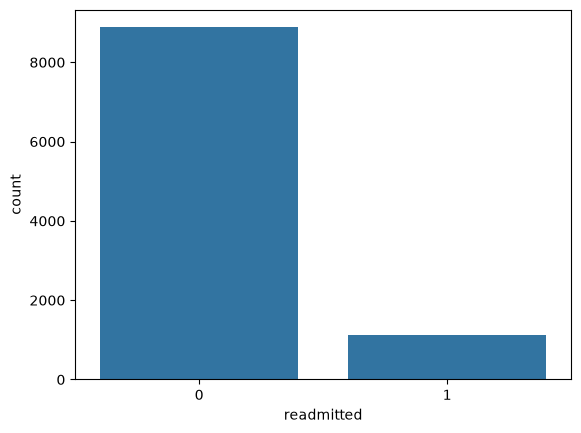

In [54]:
sns.countplot(x='readmitted', data=df.sample(10000))  

#### Time in Hospital and Readmission


Text(0.5, 1.0, 'Time in Hospital VS. Readmission')

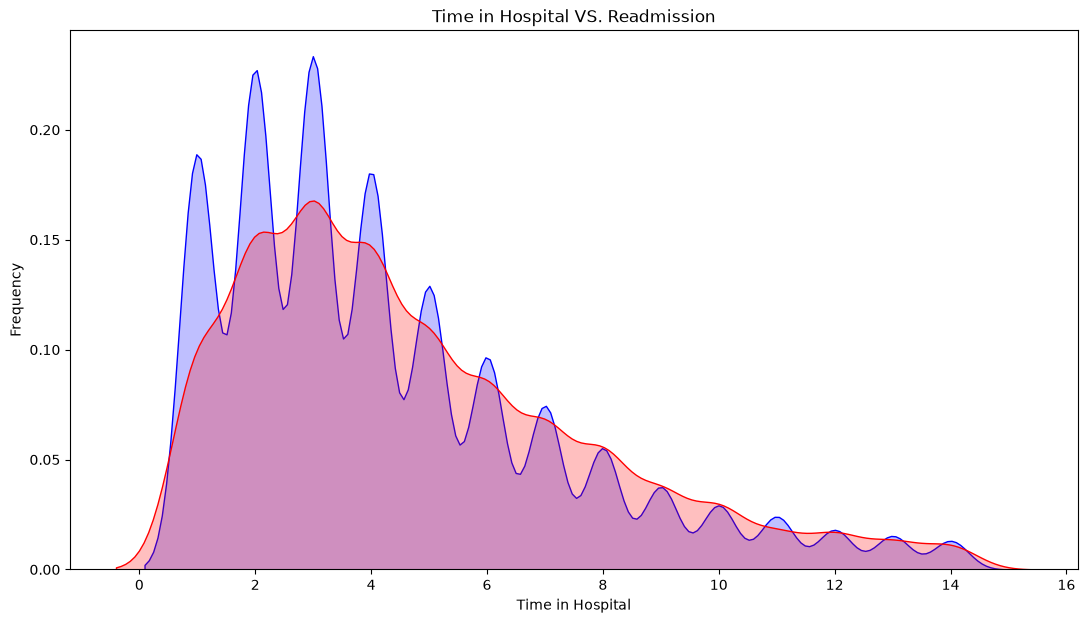

In [55]:
fig = plt.figure(figsize=(13,7),)
ax=sns.kdeplot(df.loc[(df['readmitted'] == 0),'time_in_hospital'] , color='b',shade=True,label='Not Readmitted')
ax=sns.kdeplot(df.loc[(df['readmitted'] == 1),'time_in_hospital'] , color='r',shade=True, label='Readmitted')
ax.set(xlabel='Time in Hospital', ylabel='Frequency')
plt.title('Time in Hospital VS. Readmission')

#### Age and Readmission

Text(0.5, 1.0, 'Age of Patient VS. Readmission')

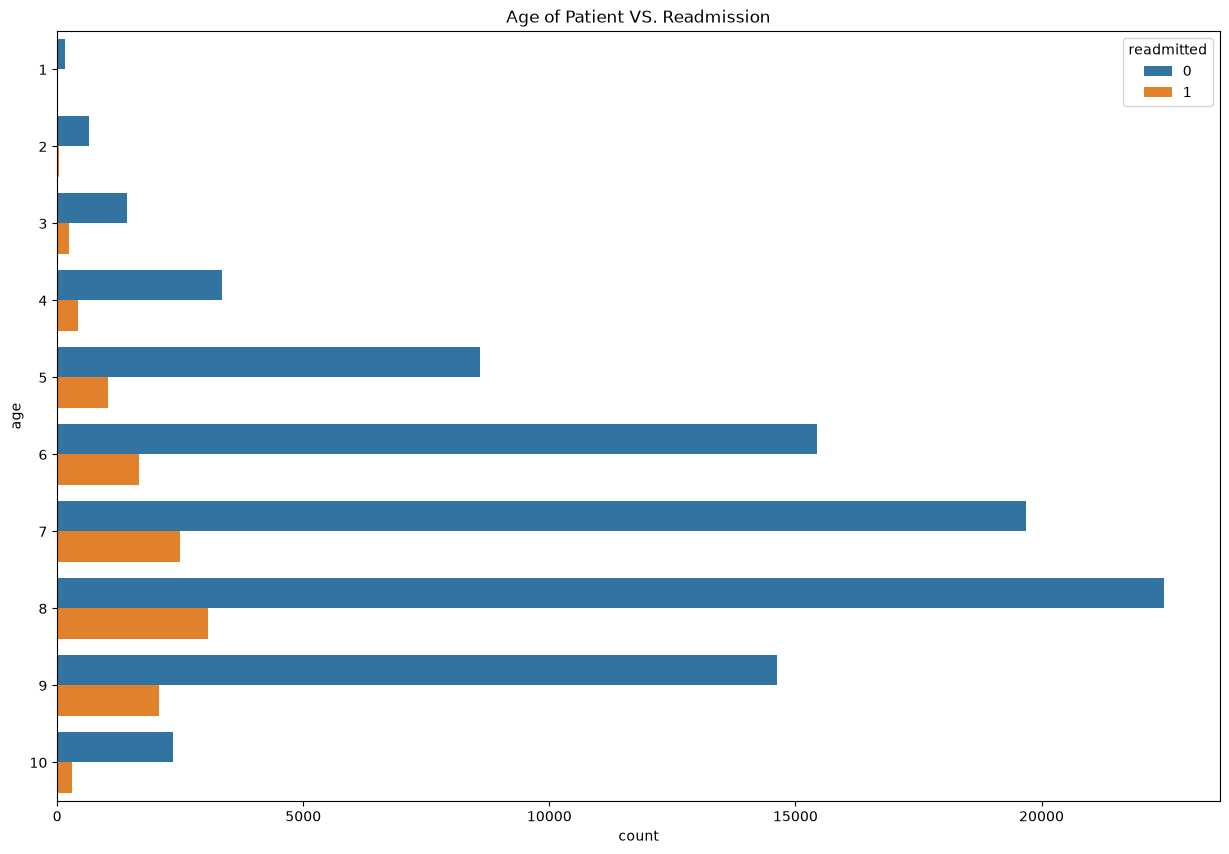

In [56]:
fig = plt.figure(figsize=(15,10))
sns.countplot(y= df['age'], hue = df['readmitted']).set_title('Age of Patient VS. Readmission')

#### Number of medication used and Readmission

Text(0.5, 1.0, 'Number of medication used VS. Readmission')

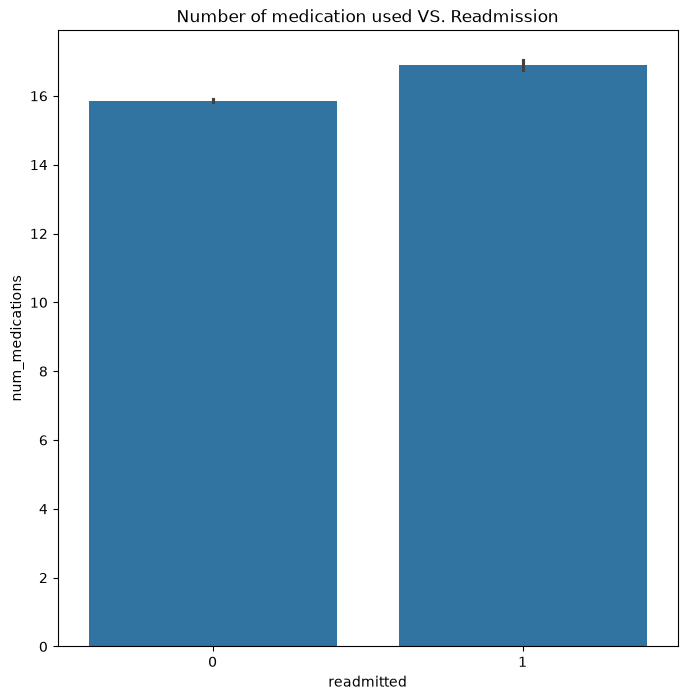

In [57]:
fig = plt.figure(figsize=(8,8))
sns.barplot(x = df['readmitted'], y = df['num_medications']).set_title("Number of medication used VS. Readmission")

#### Gender and Readmission
* Male = 1
* Female = 0

<Axes: xlabel='gender', ylabel='count'>

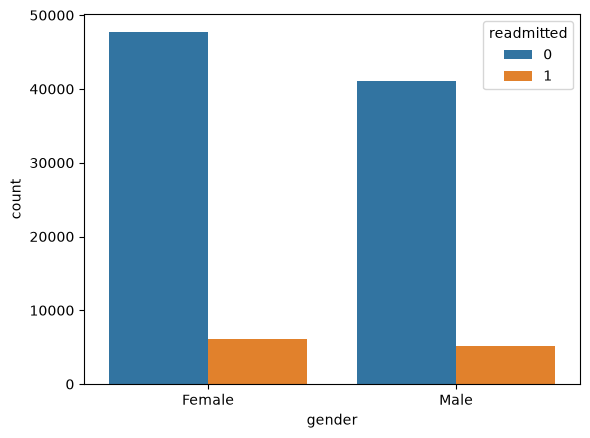

In [58]:
sns.countplot(x='gender', hue='readmitted', data=df)

#### Change of Medication and Readmission
* Change = 1
* No Change = 0

Text(0.5, 1.0, 'Change of Medication vs. Readmission')

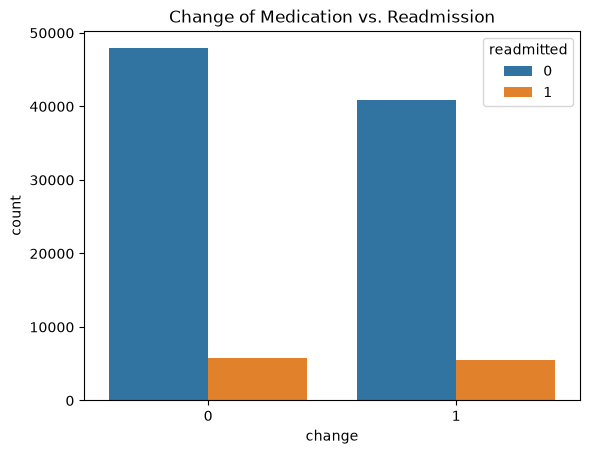

In [59]:
sns.countplot(x='change', hue='readmitted', data=df).set_title('Change of Medication vs. Readmission')

#### Diabetes Medication prescribed and Readmission
* Values la: yes = 1, no = 0

Text(0.5, 1.0, 'Diabetes Medication Prescribed vs Readmission')

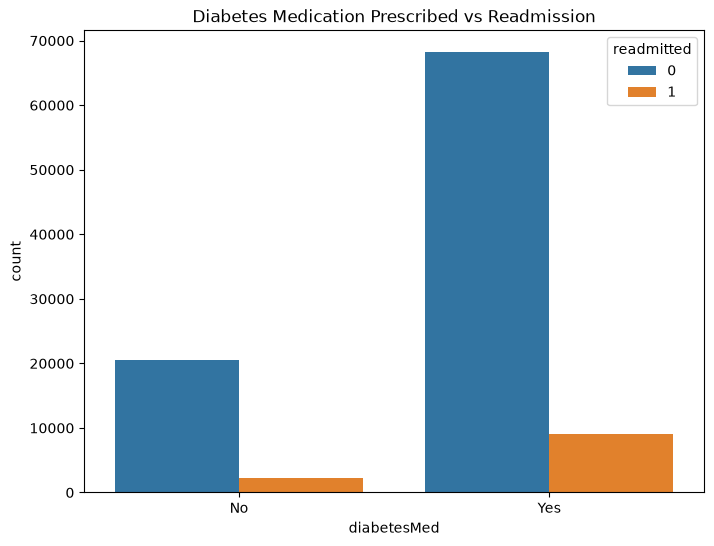

In [60]:
fig = plt.figure(figsize=(8, 6))
sns.countplot(x='diabetesMed', hue='readmitted', data=df).set_title('Diabetes Medication Prescribed vs Readmission')

#### Service Utilization and Readmission


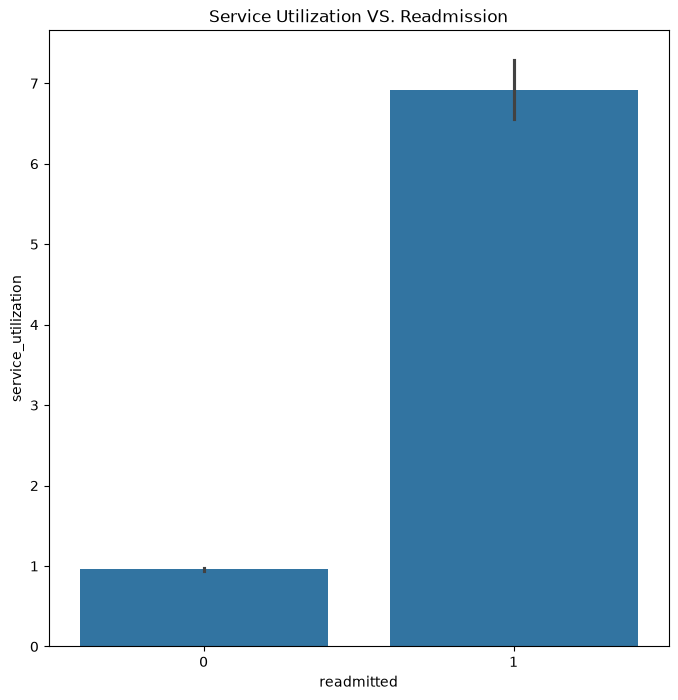

In [61]:
fig = plt.figure(figsize=(8,8))
sns.barplot(
    y=df_agg['service_utilization'],
    x=df_agg['readmitted']
).set_title('Service Utilization VS. Readmission')

plt.show()

#### Number of lab procedure and Readmission

Text(0.5, 1.0, 'Number of lab procedure VS. Readmission')

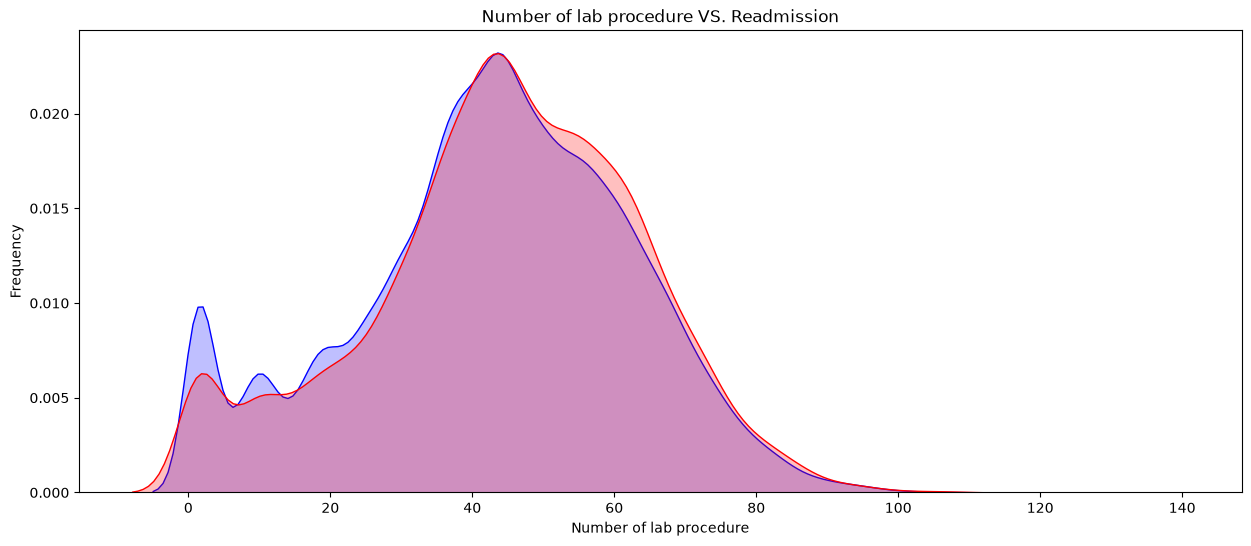

In [62]:
fig = plt.figure(figsize=(15,6),)
ax=sns.kdeplot(df.loc[(df['readmitted'] == 0),'num_lab_procedures'] , color='b',shade=True,label='Not readmitted')
ax=sns.kdeplot(df.loc[(df['readmitted'] == 1),'num_lab_procedures'] , color='r',shade=True, label='readmitted')
ax.set(xlabel='Number of lab procedure', ylabel='Frequency')
plt.title('Number of lab procedure VS. Readmission')

In [63]:
df.to_csv("filepredict.csv", index=False)